# Summative Lab – Analytics Firm Clients: Customer Reviews Analysis

This notebook is a **starter notebook** for the three parts of the lab:

1. NLP  
2. Time Series  
3. Neural Networks  

Use the comments and TODO prompts to guide your work. The notebook is intentionally incomplete so you can implement the analysis yourself.


## Part 1: NLP

In this section, you will clean and preprocess review text, explore frequent words and bigrams, and visualize key language patterns in the dataset.


In [1]:
# =========================
# Part 1: NLP Starter Code
# =========================


# TODO: Import the libraries you need for:
# - data handling
# - plotting
# - text preprocessing
# - tokenization / stopwords / lemmatization
# - counting words and bigrams

import os
import re
import string
import warnings
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.util import ngrams
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)



In [2]:

# TODO: Download any required NLTK resources.

# punkt and punkt_tab support tokenization.
# stopwords provides common English stopwords.
# wordnet and omw-1.4 support lemmatization.


required_nltk_resources = ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"]
for resource in required_nltk_resources:
    nltk.download(resource, quiet=True)
print("Required NLTK resources have been downloaded.")


# TODO: Load the dataset.
# Hint: The file used in this lab is 'amazon_reviews_lab.csv'
# df = ...
DATA_PATH = "amazon_reviews_lab.csv"
df = pd.read_csv(DATA_PATH)
print("Dataset loaded successfully.")

# TODO: Explore the dataset.
# Suggested checks:
# - shape
# - value counts for the rating column
# - preview the first few rows

print("Dataset shape:")
print(df.shape)
print("\nDataset columns:")
print(df.columns.tolist())
print("\nFirst five records:")
display(df.head())
print("\nData types:")
display(df.dtypes.to_frame(name="data_type"))
print("\nMissing values:")
display(df.isna().sum().to_frame(name="missing_values"))
print("\nNumber of exact duplicate rows:")
print(df.duplicated().sum())
print("\nRating distribution:")
display(df["rating"].value_counts(dropna=False).sort_index().to_frame(name="number_of_reviews"))




# Reflection prompt:
# What do the most common words or phrases suggest about customer sentiment or product experience?


Required NLTK resources have been downloaded.
Dataset loaded successfully.
Dataset shape:
(997, 9)

Dataset columns:
['product_id', 'rating', 'review_text', 'review_summary', 'review_time_raw', 'unix_review_time', 'timestamp', 'sentiment_label', 'review_length_words']

First five records:


,product_id,rating,review_text,review_summary,review_time_raw,unix_review_time,timestamp,sentiment_label,review_length_words
0,6301977173,2,"This film is definitely not for anyone who is especially fond of the independent, delightfully manipulative and clev...",The best of Mark Twain's work - left out!,"05 12, 2000",9.580896e+08,2000-05-12,negative,302
1,6301977173,5,This movie was playing at Radio City Music Hall back in the days of the movie/stage show formt. It was also presente...,The best Tom Sawyer i ever saw.,"08 26, 2002",1.030320e+09,2002-08-26,positive,168
2,6301977173,1,I would love to buy this movie as I have been to Hannibal Missouri and been to all the Mark Twain atractions.To buy ...,Why no Widescreen?,"08 6, 2005",1.123286e+09,2005-08-06,negative,60
3,6301977173,1,The advertisment for this DVD on Amazon was incorrect. The ad stated that the DVD was in Wide Screen Anamorphic form...,False advertising on this DVD,"09 11, 2005",1.126397e+09,2005-09-11,negative,104
4,9575871979,5,I bought some of these to try with a light using 123 A's. They work as advertised. When you check them with a meter ...,Work GREAT!!,"10 15, 2007",1.192406e+09,2007-10-15,positive,60



Data types:


,data_type
product_id,str
rating,int64
review_text,str
review_summary,str
review_time_raw,str
unix_review_time,float64
timestamp,str
sentiment_label,str
review_length_words,int64



Missing values:


,missing_values
product_id,0
rating,0
review_text,0
review_summary,0
review_time_raw,0
unix_review_time,0
timestamp,0
sentiment_label,0
review_length_words,0



Number of exact duplicate rows:
0

Rating distribution:


,number_of_reviews
rating,
1,87
2,48
3,94
4,188
5,580


### Initial exploration

The dataset contains 997 observations with no missing values in the supplied columns. The rating distribution is strongly concentrated in the higher ratings: ratings of 5 account for 580 reviews, followed by rating 4 with 188 reviews. Ratings 1, 2 and 3 contain only 87, 48 and 94 reviews respectively.

This imbalance matters later because a model can obtain a reasonable overall accuracy by predicting the majority class while performing poorly on the less common ratings.


Number of stopwords used: 207
Original records: 997
Records retained for NLP: 997
Records removed: 0


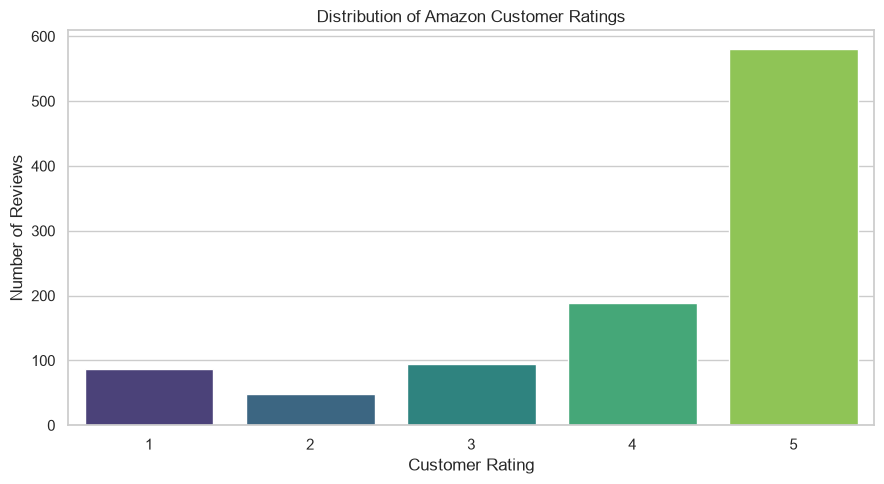

Percentage distribution of ratings:


,percentage
rating,
1,8.73
2,4.81
3,9.43
4,18.86
5,58.17


Original sample:
Great battery-life! I purchased 2 units from https://example.com and they worked perfectly.

Processed sample:
['great', 'batterylife', 'purchased', 'unit', 'worked', 'perfectly']


,review_text,clean_text,clean_token_count
0,"This film is definitely not for anyone who is especially fond of the independent, delightfully manipulative and clev...",film definitely anyone especially fond independent delightfully manipulative clever boy brain child samuel clemens c...,159
1,This movie was playing at Radio City Music Hall back in the days of the movie/stage show formt. It was also presente...,movie playing radio city music hall back day moviestage show formt presented huge radio city screen remember impress...,81
2,I would love to buy this movie as I have been to Hannibal Missouri and been to all the Mark Twain atractions.To buy ...,love buy movie hannibal missouri mark twain atractionsto buy movie real treat panscan forget dont buy full screen mo...,29
3,The advertisment for this DVD on Amazon was incorrect. The ad stated that the DVD was in Wide Screen Anamorphic form...,advertisment dvd incorrect stated dvd wide screen anamorphic format dvd format standard pan scan poor quality transf...,46
4,I bought some of these to try with a light using 123 A's. They work as advertised. When you check them with a meter ...,bought try light using work advertised check meter show volt load hurt light using hold charge well longer buy throw...,21


,review_text,clean_text,clean_token_count
453,This is exactly what I needed for my SU-800 wireless flash commander. It sure beats buying these batteries as often ...,exactly needed wireless flash commander sure beat buying battery often definitely recommend,12
792,Purchased this after the purchase of a camcorder that required it and would not work with a 16gig. Got the smaller c...,purchased purchase camcorder required work gig smaller card local store price wanted compare first haft price buying...,30
209,Very solid...we mounted our flat panel in the bedroom. Like the tipping feature and love the articulating feature.We...,solidwe mounted flat panel bedroom like tipping feature love articulating featurewe checked price store big box etc ...,21
309,I purchased a NOOKcolor a couple of months after it came out. Within a week I had to return it because it would not ...,purchased nookcolor couple month came within week return charge lot hassle required replacement took couple week set...,122
739,I bought the hd first and am completely in love with it. A very handy size and very responsive. Bought the hd+ for u...,bought first completely love handy size responsive bought use size factor love added gig scandisk real issue run ubu...,42


Reviews with no tokens after preprocessing: 0.00%

Summary of tokens retained per review:


count     997.000000
mean       68.233701
std       102.664260
min         3.000000
25%        14.000000
50%        29.000000
75%        77.000000
max      1003.000000
Name: clean_token_count, dtype: float64

In [3]:
# TODO: Create preprocessing tools such as:
# - stop_words
# - lemmatizer
stop_words = set(stopwords.words("english"))
custom_stopwords = {"amazon", "product", "item", "would", "could", "also", "one", "get", "got"}

stop_words.update(custom_stopwords)

# Create the lemmatizer.
lemmatizer = WordNetLemmatizer()
print(f"Number of stopwords used: {len(stop_words):,}")

nlp_df = df.dropna(subset=["review_text", "rating"]).copy()
nlp_df["review_text"] = nlp_df["review_text"].astype(str)
nlp_df = nlp_df.drop_duplicates(subset=["product_id", "review_text", "rating"]).copy()
print(f"Original records: {len(df):,}")
print(f"Records retained for NLP: {len(nlp_df):,}")
print(f"Records removed: {len(df) - len(nlp_df):,}")


# Visualize the rating distribution.
plt.figure(figsize=(9, 5))
sns.countplot(data=nlp_df,x="rating",palette="viridis")
plt.title("Distribution of Amazon Customer Ratings")
plt.xlabel("Customer Rating")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

# Display rating proportions.
rating_proportions = (nlp_df["rating"].value_counts(normalize=True).sort_index().mul(100).round(2))
print("Percentage distribution of ratings:")
display(rating_proportions.to_frame(name="percentage"))

# TODO: Write a function called preprocess_text(text) that:
# 1. converts text to lowercase
# 2. removes URLs
# 3. removes punctuation
# 4. tokenizes the text
# 5. keeps alphabetic tokens only
# 6. removes stopwords
# 7. lemmatizes the remaining tokens
# 8. returns the cleaned tokens

# def preprocess_text(text):
#     pass


def preprocess_text(text):
    """
    Clean one customer review and return a list of meaningful,
    lemmatized tokens.
    """

    # Return an empty list if the input is missing.
    if pd.isna(text):
        return []

    
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+"," ",text)
    text = re.sub(r"<[^>]+>"," ",text)
    text = re.sub(r"&[a-z]+;"," ",text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+"," ",text)
    text = re.sub(r"\s+"," ",text).strip()

    tokens = word_tokenize(text)
    cleaned_tokens = []

    for token in tokens:

        if (
            token.isalpha()
            and len(token) > 2
            and token not in stop_words
        ):
            cleaned_token = lemmatizer.lemmatize(token)
            cleaned_tokens.append(cleaned_token)

    return cleaned_tokens


# Test the preprocessing function before applying it

sample_review = (
    "Great battery-life! I purchased 2 units from "
    "https://example.com and they worked perfectly."
)

print("Original sample:")
print(sample_review)

print("\nProcessed sample:")
print(preprocess_text(sample_review))

# TODO: Apply your preprocessing function to the review text column
# and store the output in a new column such as 'processed_tokens'.


nlp_df["processed_tokens"] = (nlp_df["review_text"].apply(preprocess_text))
nlp_df["clean_text"] = (nlp_df["processed_tokens"].apply(" ".join))
nlp_df["clean_token_count"] = (nlp_df["processed_tokens"].apply(len))
display(nlp_df[["review_text","clean_text","clean_token_count"]].head())


# Display a reproducible sample comparing original and cleaned text.
preprocessing_sample = nlp_df.sample(n=min(5, len(nlp_df)),random_state=RANDOM_STATE)
display(preprocessing_sample[["review_text", "clean_text", "clean_token_count"]])

# Percentage of reviews left without tokens.
empty_token_percentage = nlp_df["clean_token_count"].eq(0).mean() * 100
print(f"Reviews with no tokens after preprocessing: {empty_token_percentage:.2f}%")
print("\nSummary of tokens retained per review:")
display(nlp_df["clean_token_count"].describe())




### Preprocessing interpretation

The preprocessing pipeline includes: lowercase conversion, URL removal, punctuation removal, tokenization, alphabetic-token filtering, stopword removal and lemmatization.

These steps reduce noise while retaining words that are more useful for identifying customer themes. lemmatization helps group related word forms. Stopword removal reduces very common words that are unlikely to distinguish product experiences.

A trade-off is that aggressive cleaning can remove context or sentiment-bearing expressions. 

Total cleaned tokens: 68,029
Number of unique tokens: 8,526


,word,frequency
0,nook,1518
1,book,914
2,kindle,566
3,screen,498
4,like,460
5,read,454
6,work,447
7,great,422
8,use,421
9,tablet,421


,bigram,frequency
0,barnes noble,152
1,nook color,128
2,battery life,87
3,touch screen,82
4,nook tablet,65
5,work great,63
6,kindle fire,58
7,work well,57
8,read book,57
9,wall mount,52


,trigram,frequency
0,nook simple touch,36
1,barnes noble nook,12
2,adobe digital edition,10
3,barnes noble store,9
4,access google play,8
5,google play store,8
6,book barnes noble,7
7,access android market,7
8,apps google play,7
9,microsd card slot,6


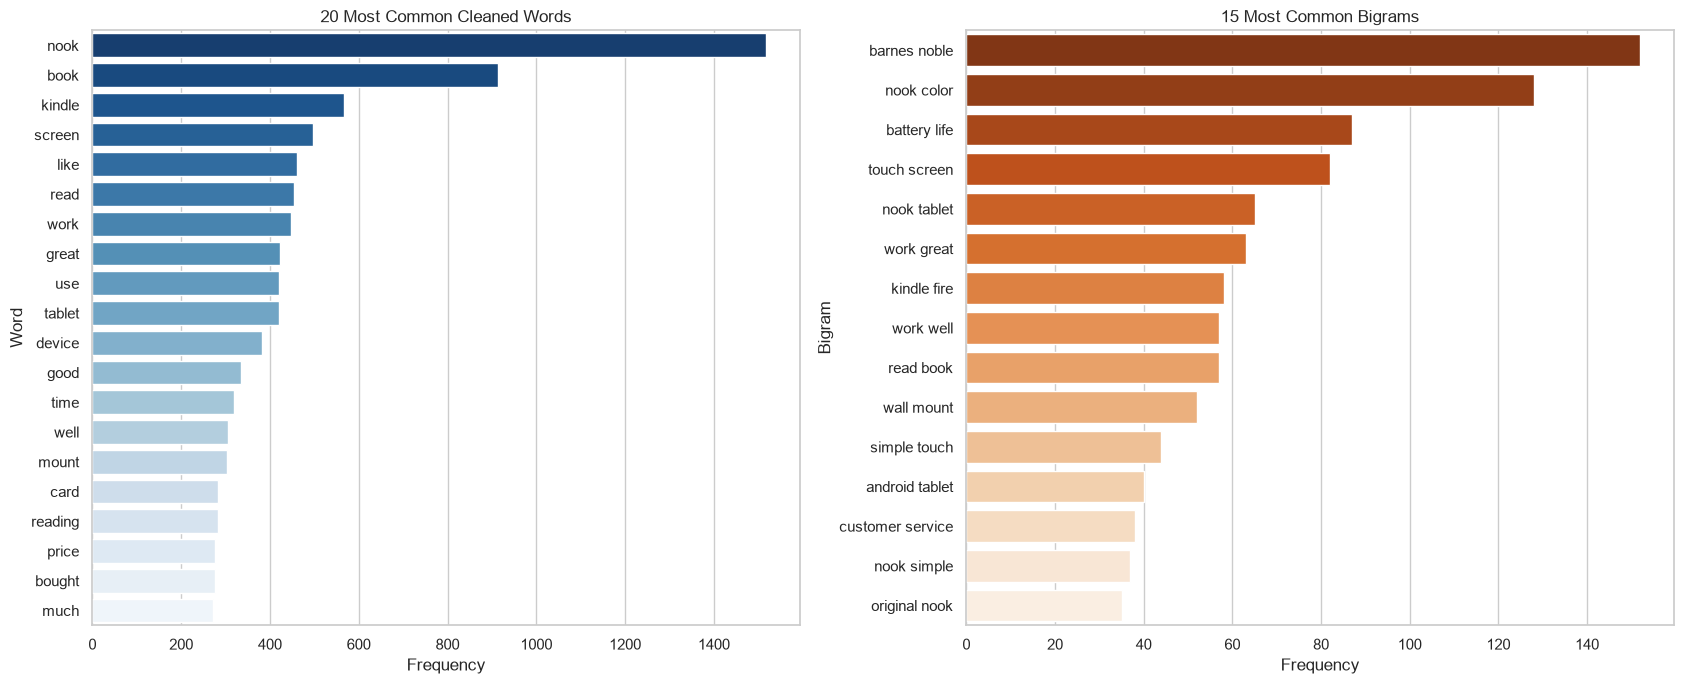

,sentiment,term,frequency
0,negative,nook,255
1,negative,book,191
2,negative,device,84
3,negative,read,83
4,negative,kindle,80


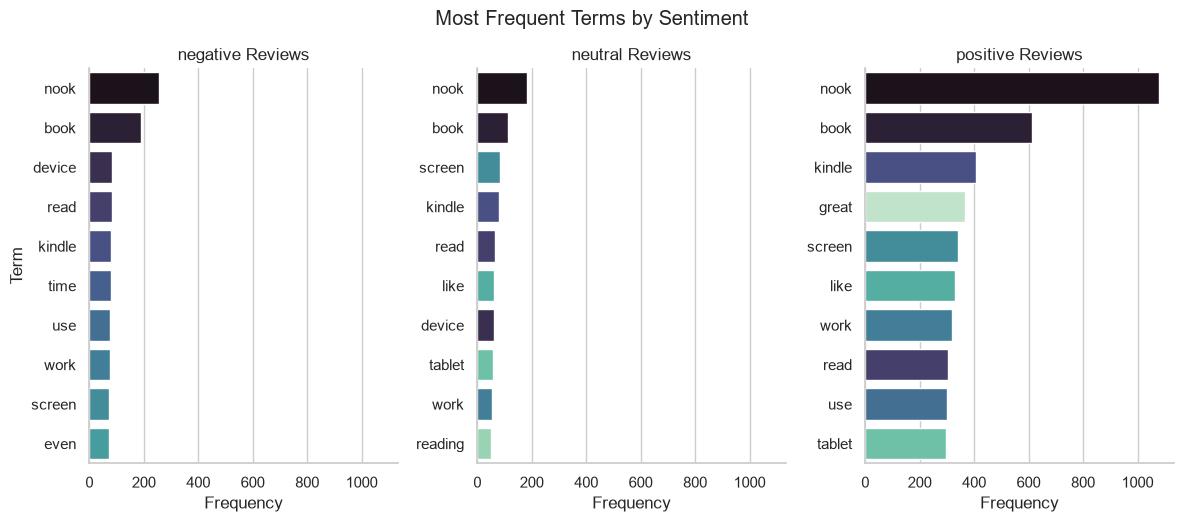

In [4]:
# TODO: Combine all tokens into one list so you can compute word frequencies.

all_tokens = [
    token
    for token_list in nlp_df["processed_tokens"]
    for token in token_list
]

print(f"Total cleaned tokens: {len(all_tokens):,}")
print(f"Number of unique tokens: {len(set(all_tokens)):,}")


# TODO: Use Counter to identify the most common words.

word_counter = Counter(all_tokens)
most_common_words = pd.DataFrame(word_counter.most_common(20), columns=["word", "frequency"])

display(most_common_words)

# TODO: Generate bigrams from the token list and identify the most common bigrams.
# Bigrams are generated separately within each review.
# This avoids creating artificial bigrams across review boundaries.

bigram_counter = Counter()

for token_list in nlp_df["processed_tokens"]:
    bigram_counter.update(
        ngrams(token_list, 2)
    )

most_common_bigrams = pd.DataFrame([(" ".join(bigram), frequency) for bigram, frequency in bigram_counter.most_common(20)], columns=["bigram", "frequency"])
display(most_common_bigrams)
trigram_counter = Counter()

for token_list in nlp_df["processed_tokens"]:
    trigram_counter.update(
        ngrams(token_list, 3)
    )

most_common_trigrams = pd.DataFrame(
    [
        (" ".join(trigram), frequency)
        for trigram, frequency
        in trigram_counter.most_common(15)
    ],
    columns=[
        "trigram",
        "frequency"
    ]
)

display(most_common_trigrams)

# TODO: Create at least one visualization of the most common words.
# You may also choose to visualize the most common bigrams.

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

sns.barplot(data=most_common_words, x="frequency", y="word", palette="Blues_r", ax=axes[0])
axes[0].set_title("20 Most Common Cleaned Words")
axes[0].set_xlabel("Frequency")
axes[0].set_ylabel("Word")

sns.barplot(data=most_common_bigrams.head(15), x="frequency", y="bigram", palette="Oranges_r", ax=axes[1])
axes[1].set_title("15 Most Common Bigrams")
axes[1].set_xlabel("Frequency")
axes[1].set_ylabel("Bigram")

plt.tight_layout()
plt.show()

# Compare term distributions across sentiment categories.

sentiment_term_records = []
for sentiment, group in nlp_df.groupby("sentiment_label"):
    sentiment_tokens = [
        token
        for token_list in group["processed_tokens"]
        for token in token_list
    ]
    sentiment_counter = Counter(sentiment_tokens)
    for term, frequency in sentiment_counter.most_common(10):
        sentiment_term_records.append(
            {
                "sentiment": sentiment,
                "term": term,
                "frequency": frequency
            }
        )

sentiment_terms = pd.DataFrame(sentiment_term_records)
display(sentiment_terms.head())

# TODO: Visualize the top terms within each sentiment category.

sentiment_plot = sns.catplot(
    data=sentiment_terms,
    x="frequency",
    y="term",
    col="sentiment",
    kind="bar",
    sharey=False,
    height=5,
    aspect=0.8,
    palette="mako"
)

sentiment_plot.set_axis_labels("Frequency", "Term")
sentiment_plot.set_titles("{col_name} Reviews")
sentiment_plot.fig.suptitle("Most Frequent Terms by Sentiment", y=1.04)
plt.show()


## Part 1 Reflection

The most frequently used words in the reviews are terms such as Nook, books, Kindle, screen, reading, and tablet. This shows that customers are mainly talking about e-readers and tablets and how they use these devices.

The most common word pairs include Barnes Noble, Nook Color, battery life, touch screen, Nook HD, and SD card. These phrases give more useful information than single words because they highlight specific products, features, and issues that customers care about.

Comments about battery life, touch screen, customer service, and works great suggest that customers discuss both how well the products perform and their overall experience with the company and its services. By identifying these recurring topics, an analytics team can better understand what matters most to customers and which areas may need improvement.

## Part 2: Time Series

In this section, you will analyze review activity over time by converting timestamps, resampling the data, and visualizing trends in review volume and ratings.


In [16]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

In [17]:

DATA_PATH = "amazon_reviews_lab.csv"
df = pd.read_csv(DATA_PATH)
ts_df = df.copy()
ts_df["timestamp"] = pd.to_datetime(
    ts_df["timestamp"],
    errors="coerce"
)

ts_df["rating"] = pd.to_numeric(
    ts_df["rating"],
    errors="coerce"
)

ts_df = (
    ts_df
    .dropna(subset=["timestamp", "rating"])
    .sort_values("timestamp")
    .copy()
)


monthly = (
    ts_df
    .set_index("timestamp")
    .resample("MS")
    .agg(
        monthly_review_count=("rating", "size"),
        monthly_avg_rating=("rating", "mean")
    )
)


monthly["monthly_review_count"] = (
    monthly["monthly_review_count"]
    .fillna(0)
    .astype(int)
)

print(monthly.head())

print(
    "Zero-review months:",
    monthly["monthly_review_count"].eq(0).sum()
)

            monthly_review_count  monthly_avg_rating
timestamp                                           
2000-05-01                     1                 2.0
2000-06-01                     0                 NaN
2000-07-01                     0                 NaN
2000-08-01                     0                 NaN
2000-09-01                     0                 NaN
Zero-review months: 103


### Interpretation:
A total of 103 months contain no review activity. The zero review counts are valid observations and should be retained in the review-volume time series. However, the missing average ratings should not be replaced with zero because zero would incorrectly imply that an actual rating was recorded. The frequency of zero-review months indicates that the time series is sparse, which should be considered when interpreting trends, testing stationarity, performing seasonal decomposition, and evaluating forecasting models.

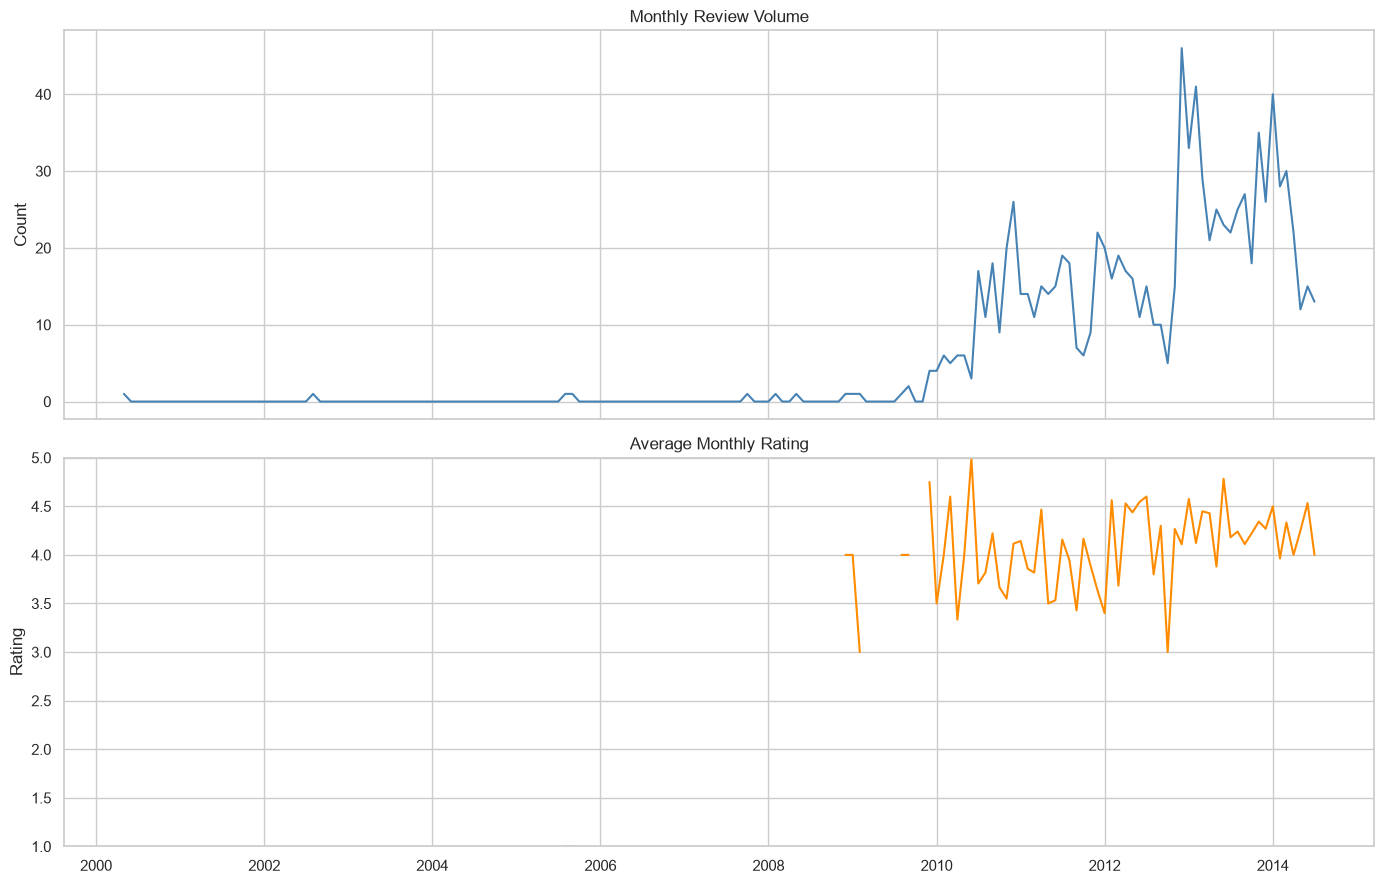

In [18]:
fig,ax=plt.subplots(2,1,figsize=(14,9),sharex=True)
ax[0].plot(monthly.index,monthly.monthly_review_count,color="steelblue"); ax[0].set_title("Monthly Review Volume"); ax[0].set_ylabel("Count")
ax[1].plot(monthly.index,monthly.monthly_avg_rating,color="darkorange"); ax[1].set_title("Average Monthly Rating"); ax[1].set_ylabel("Rating"); ax[1].set_ylim(1,5)
plt.tight_layout(); plt.show()

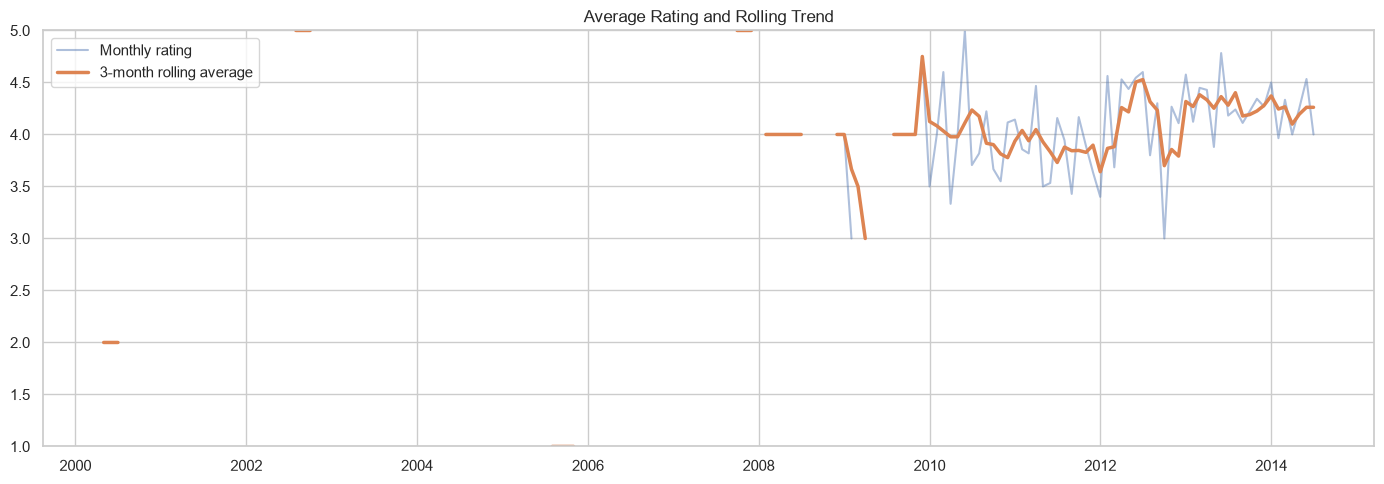

In [19]:
monthly["rating_rolling_3m"]=monthly.monthly_avg_rating.rolling(3,min_periods=1).mean()
plt.figure(figsize=(14,5))
plt.plot(monthly.index,monthly.monthly_avg_rating,alpha=.45,label="Monthly rating")
plt.plot(monthly.index,monthly.rating_rolling_3m,lw=2.5,label="3-month rolling average")
plt.title("Average Rating and Rolling Trend"); plt.ylim(1,5); plt.legend(); plt.tight_layout(); plt.show()

### Stationarity tests and transformation

In [20]:
# TODO: Test stationarity using the Augmented Dickey-Fuller test.

def adf_row(series, name):
   
    clean_series = pd.Series(series).dropna()

    result = adfuller(
        clean_series,
        autolag="AIC"
    )

    return {
        "series": name,
        "ADF statistic": result[0],
        "p-value": result[1],
        "lags": result[2],
        "observations": result[3],
        "stationary at 5%": result[1] < 0.05
    }

review_count = (
    monthly["monthly_review_count"]
    .astype(float)
)

log_count = np.log1p(
    review_count
)

log_count_diff = (
    log_count
    .diff()
    .dropna()
)


adf_results = pd.DataFrame(
    [
        adf_row(
            review_count,
            "Raw monthly review count"
        ),
        adf_row(
            log_count,
            "Log-transformed monthly review count"
        ),
        adf_row(
            log_count_diff,
            "Differenced log monthly review count"
        )
    ]
)

display(adf_results)

,series,ADF statistic,p-value,lags,observations,stationary at 5%
0,Raw monthly review count,-0.400416,0.910029,14,156,False
1,Log-transformed monthly review count,-0.971256,0.763603,13,157,False
2,Differenced log monthly review count,-2.582352,0.096700,12,157,False


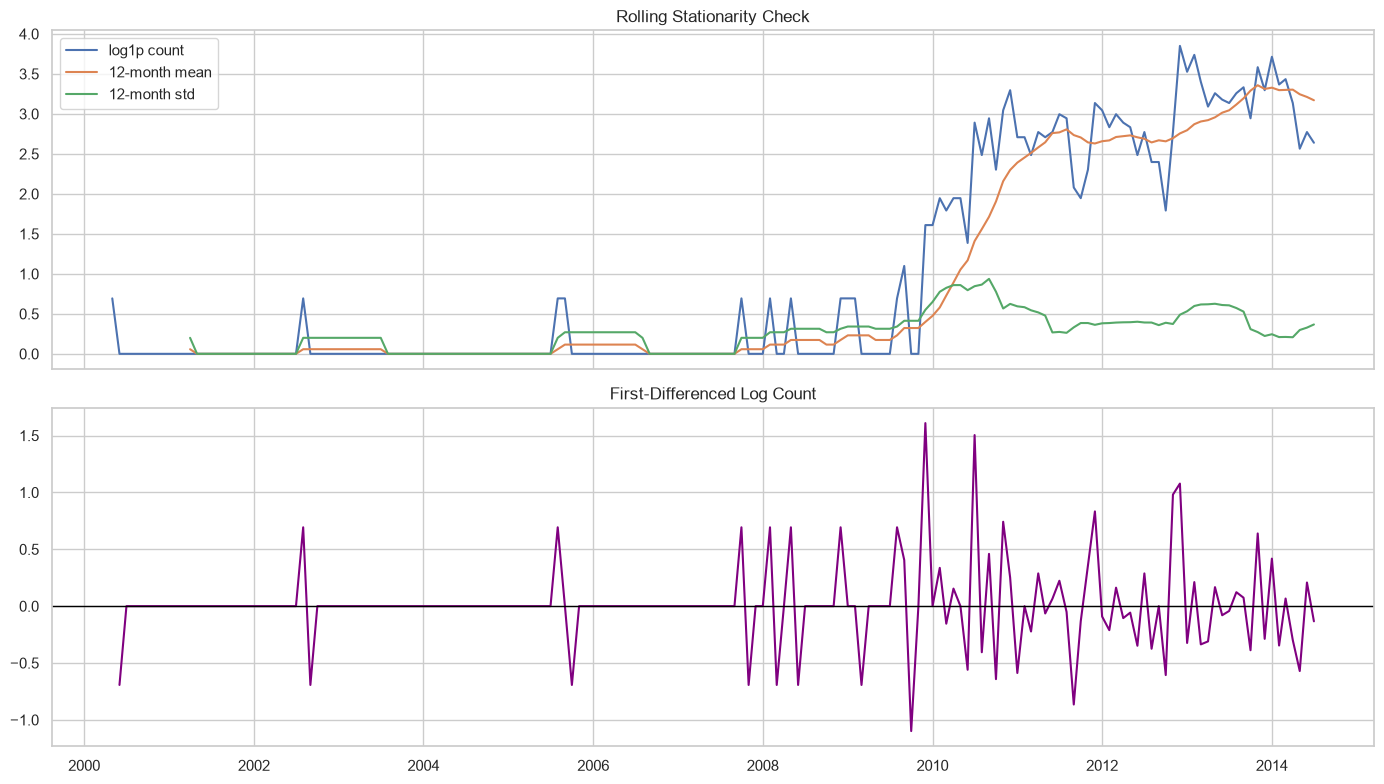

In [21]:
fig,ax=plt.subplots(2,1,figsize=(14,8),sharex=True)
ax[0].plot(log_count,label="log1p count"); ax[0].plot(log_count.rolling(12).mean(),label="12-month mean"); ax[0].plot(log_count.rolling(12).std(),label="12-month std"); ax[0].legend(); ax[0].set_title("Rolling Stationarity Check")
ax[1].plot(log_count_diff,color="purple"); ax[1].axhline(0,color="black",lw=1); ax[1].set_title("First-Differenced Log Count")
plt.tight_layout(); plt.show()

### Decomposition and ACF/PACF diagnosis

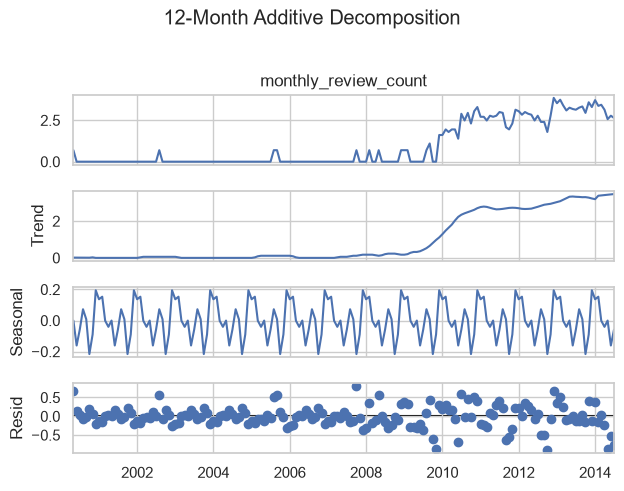

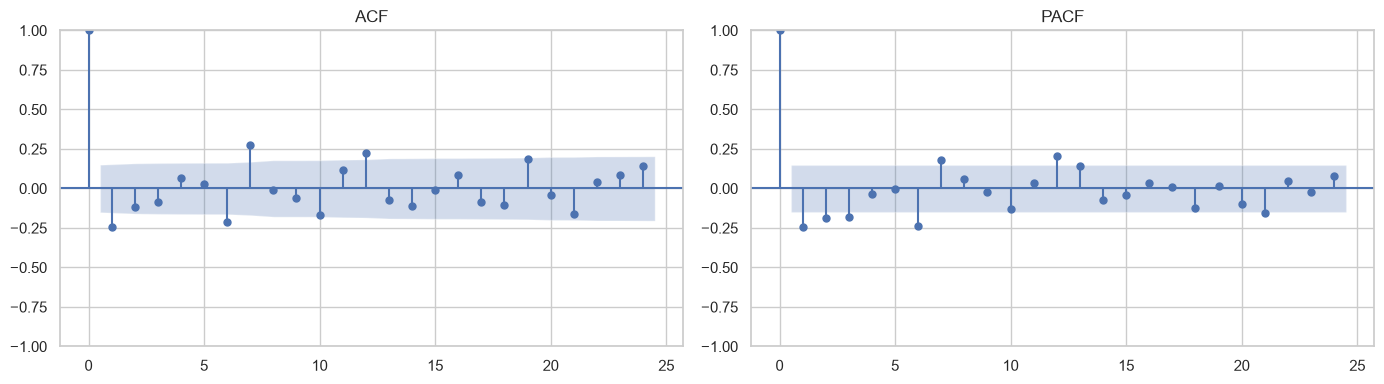

In [22]:

log_count = log_count.dropna()
log_count_diff = log_count_diff.dropna()

decomposition = seasonal_decompose(
    log_count,
    model="additive",
    period=12,
    extrapolate_trend="freq"
)

decomposition.plot()

plt.suptitle(
    "12-Month Additive Decomposition",
    y=1.02
)

plt.tight_layout()
plt.show()


L = min(
    24,
    len(log_count_diff) // 2 - 1
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 4)
)

plot_acf(
    log_count_diff,
    lags=L,
    ax=axes[0]
)

plot_pacf(
    log_count_diff,
    lags=L,
    ax=axes[1],
    method="ywm"
)

axes[0].set_title("ACF")
axes[1].set_title("PACF")

plt.tight_layout()
plt.show()

### Model selection and chronological holdout evaluation
The last 12 months are held out. Candidate models are compared using AIC/BIC and out-of-sample MAE/RMSE. MAPE is excluded because months can have zero reviews.

In [23]:
# TODO: Compare candidate ARIMA models using a chronological holdout set


# Use the denser period from January 2010 onward.
model_monthly = monthly.loc["2010-01-01":].copy()


model_monthly["monthly_review_count"] = pd.to_numeric(
    model_monthly["monthly_review_count"],
    errors="coerce"
)

model_monthly["monthly_review_count"] = (
    model_monthly["monthly_review_count"]
    .fillna(0)
    .astype(float)
)

review_count_model = model_monthly["monthly_review_count"]

log_count_model = np.log1p(review_count_model)



TEST_MONTHS = 12

if len(log_count_model) <= TEST_MONTHS:
    raise ValueError(
        "The modelling series does not contain enough observations "
        "for a 12-month holdout set."
    )


train_log = log_count_model.iloc[:-TEST_MONTHS].copy()
test_log = log_count_model.iloc[-TEST_MONTHS:].copy()
test_actual = np.expm1(test_log).to_numpy()

print(f"Total modelling months: {len(log_count_model)}")
print(f"Training months:        {len(train_log)}")
print(f"Testing months:         {len(test_actual)}")
print(
    f"Training period:        "
    f"{train_log.index.min().date()} to "
    f"{train_log.index.max().date()}"
)
print(
    f"Testing period:         "
    f"{test_log.index.min().date()} to "
    f"{test_log.index.max().date()}"
)

candidate_orders = [
    (1, 1, 0),
    (0, 1, 1),
    (1, 1, 1),
    (2, 1, 1),
    (1, 1, 2),
    (2, 1, 2)
]

model_results = []
fitted_models = {}
failed_models = []

for order in candidate_orders:

    try:
        
        fitted_model = ARIMA(
            train_log,
            order=order,
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit()

        
        forecast_log = fitted_model.forecast(
            steps=TEST_MONTHS
        )

        forecast_count = np.maximum(
            0,
            np.expm1(np.asarray(forecast_log, dtype=float))
        )

        if len(test_actual) != len(forecast_count):
            raise ValueError(
                f"Actual length {len(test_actual)} does not match "
                f"forecast length {len(forecast_count)}."
            )

        model_mae = mean_absolute_error(
            test_actual,
            forecast_count
        )

        model_rmse = np.sqrt(
            mean_squared_error(
                test_actual,
                forecast_count
            )
        )

        model_results.append(
            {
                "order": order,
                "AIC": fitted_model.aic,
                "BIC": fitted_model.bic,
                "MAE": model_mae,
                "RMSE": model_rmse
            }
        )

        fitted_models[order] = fitted_model

        print(
            f"ARIMA{order} succeeded: "
            f"MAE={model_mae:.4f}, "
            f"RMSE={model_rmse:.4f}"
        )

    except Exception as error:

        failed_models.append(
            {
                "order": order,
                "error": str(error)
            }
        )

        print(
            f"ARIMA{order} failed: "
            f"{type(error).__name__}: {error}"
        )

if len(model_results) == 0:

    failure_details = "\n".join(
        [
            f"ARIMA{failure['order']}: {failure['error']}"
            for failure in failed_models
        ]
    )

    raise RuntimeError(
        "None of the candidate ARIMA models fitted successfully.\n\n"
        f"{failure_details}"
    )

comparison = (
    pd.DataFrame(model_results)
    .sort_values(
        by=["RMSE", "MAE", "AIC"],
        ascending=[True, True, True]
    )
    .reset_index(drop=True)
)

print("\nCandidate ARIMA model comparison:")
display(comparison)


best_order = tuple(
    comparison.loc[0, "order"]
)

best_model = fitted_models[best_order]

print(f"\nSelected model: ARIMA{best_order}")
print(f"Holdout MAE:  {comparison.loc[0, 'MAE']:.4f}")
print(f"Holdout RMSE: {comparison.loc[0, 'RMSE']:.4f}")
print(f"AIC:          {comparison.loc[0, 'AIC']:.4f}")
print(f"BIC:          {comparison.loc[0, 'BIC']:.4f}")

Total modelling months: 55
Training months:        43
Testing months:         12
Training period:        2010-01-01 to 2013-07-01
Testing period:         2013-08-01 to 2014-07-01
ARIMA(1, 1, 0) succeeded: MAE=7.2145, RMSE=8.5574
ARIMA(0, 1, 1) succeeded: MAE=7.1487, RMSE=8.4687
ARIMA(1, 1, 1) succeeded: MAE=8.0996, RMSE=9.7440
ARIMA(2, 1, 1) succeeded: MAE=8.1954, RMSE=9.9408
ARIMA(1, 1, 2) succeeded: MAE=8.2208, RMSE=9.9811
ARIMA(2, 1, 2) succeeded: MAE=8.0468, RMSE=9.7055

Candidate ARIMA model comparison:


,order,AIC,BIC,MAE,RMSE
0,"(0, 1, 1)",56.336733,59.714492,7.148724,8.468655
1,"(1, 1, 0)",57.612540,61.039684,7.214477,8.557374
2,"(2, 1, 2)",56.253277,64.571085,8.046829,9.705518
3,"(1, 1, 1)",54.704960,59.771598,8.099628,9.744037
4,"(2, 1, 1)",57.471916,64.227434,8.195449,9.940830
5,"(1, 1, 2)",56.554008,63.208255,8.220750,9.981116



Selected model: ARIMA(0, 1, 1)
Holdout MAE:  7.1487
Holdout RMSE: 8.4687
AIC:          56.3367
BIC:          59.7145


Selected model: ARIMA(0, 1, 1)


,order,AIC,BIC,MAE,RMSE
0,"(0, 1, 1)",56.336733,59.714492,7.148724,8.468655


,Actual,Forecast
Month,,
2013-08-01,25.0,22.607657
2013-09-01,27.0,22.607657
2013-10-01,18.0,22.607657
2013-11-01,35.0,22.607657
2013-12-01,26.0,22.607657
2014-01-01,40.0,22.607657
2014-02-01,28.0,22.607657
2014-03-01,30.0,22.607657
2014-04-01,22.0,22.607657


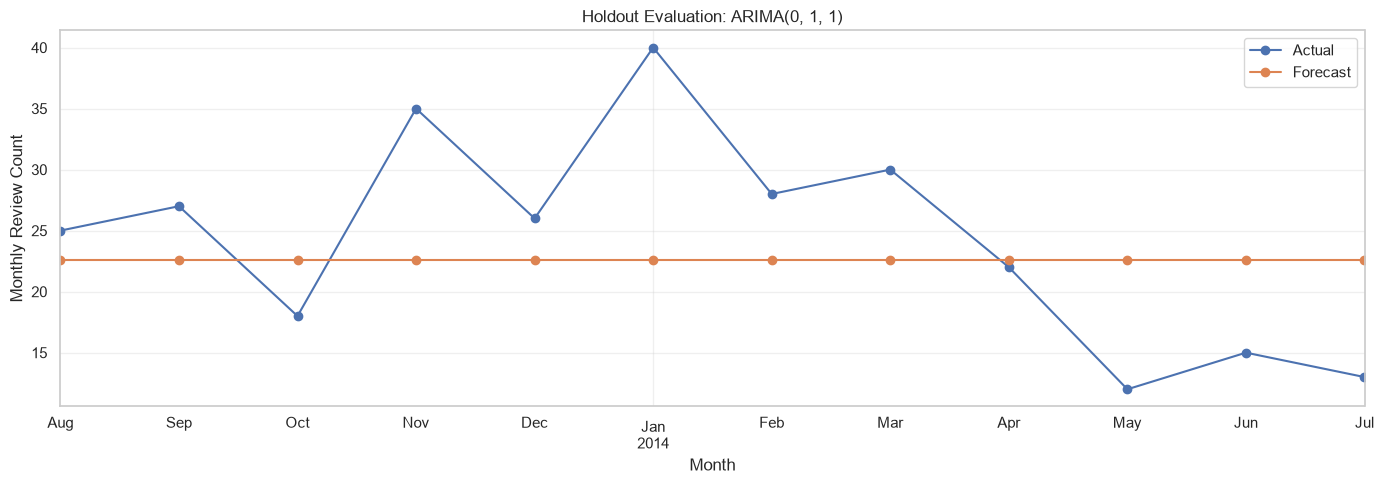

In [24]:

if comparison.empty:
    raise RuntimeError("No ARIMA candidate fitted successfully.")

best_order = tuple(comparison.loc[0, "order"])
best_model = fitted_models[best_order]
best_pred = np.maximum(
    0,
    np.expm1(
        best_model.forecast(steps=TEST_MONTHS)
    )
)
actual_values = np.asarray(
    test_actual,
    dtype=float
).reshape(-1)

forecast_values = np.asarray(
    best_pred,
    dtype=float
).reshape(-1)

if len(actual_values) != len(forecast_values):
    raise ValueError(
        f"Actual values contain {len(actual_values)} observations, "
        f"but the forecast contains {len(forecast_values)} observations."
    )

holdout_index = test_log.index

if len(holdout_index) != len(actual_values):
    raise ValueError(
        f"The test index contains {len(holdout_index)} dates, "
        f"but the actual values contain {len(actual_values)} observations."
    )

print(f"Selected model: ARIMA{best_order}")
display(comparison.iloc[[0]])

# Create the holdout comparison table
holdout_comparison = pd.DataFrame(
    {
        "Actual": actual_values,
        "Forecast": forecast_values
    },
    index=holdout_index
)

holdout_comparison.index.name = "Month"

display(holdout_comparison)
holdout_comparison.plot(
    figsize=(14, 5),
    marker="o"
)

plt.title(
    f"Holdout Evaluation: ARIMA{best_order}"
)

plt.xlabel("Month")
plt.ylabel("Monthly Review Count")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Final 12-month forecast with uncertainty

Final model: ARIMA(0, 1, 1)
Forecast horizon: 12 months


,forecast,lower_95,upper_95
Month,,,
2014-08-01,13.80894,5.312323,33.742316
2014-09-01,13.80894,4.410960,39.529723
2014-10-01,13.80894,3.735004,45.315636
2014-11-01,13.80894,3.202153,51.188659
2014-12-01,13.80894,2.768156,57.199469
2015-01-01,13.80894,2.406342,63.381298
2015-02-01,13.80894,2.099354,69.758189
2015-03-01,13.80894,1.835266,76.348895
2015-04-01,13.80894,1.605531,83.168920


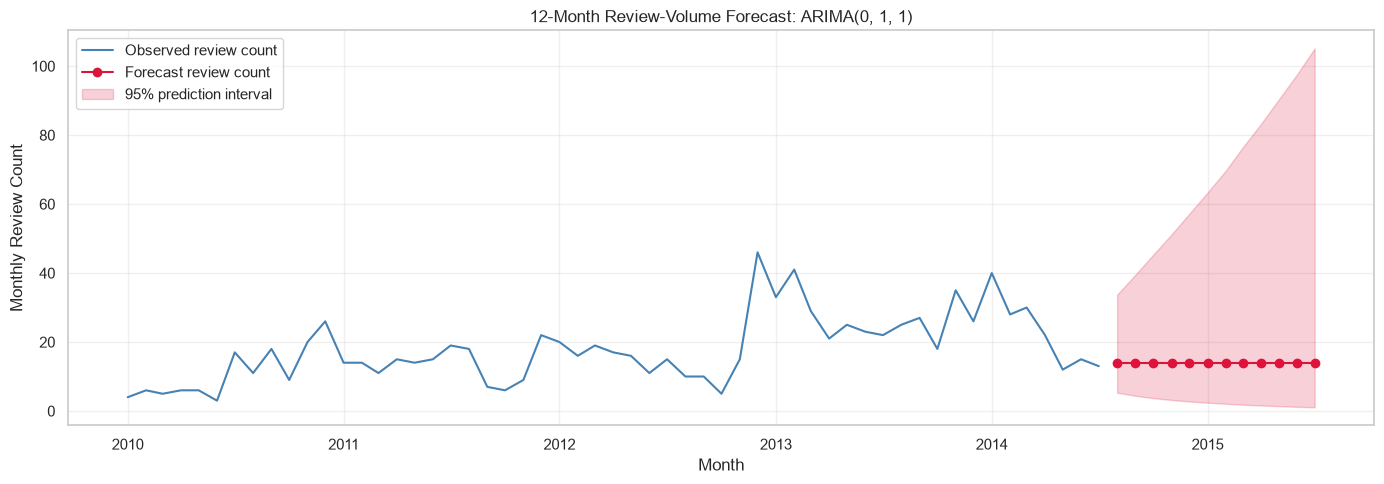

In [25]:
# TODO: Refit the selected ARIMA model and forecast the next 12 months


final_fit = ARIMA(
    log_count_model,
    order=best_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit()


FORECAST_MONTHS = 12

forecast_result = final_fit.get_forecast(
    steps=FORECAST_MONTHS
)


forecast_mean = np.maximum(
    0,
    np.expm1(
        np.asarray(
            forecast_result.predicted_mean,
            dtype=float
        )
    )
)


forecast_ci_log = forecast_result.conf_int(
    alpha=0.05
)


forecast_lower = np.maximum(
    0,
    np.expm1(
        np.asarray(
            forecast_ci_log.iloc[:, 0],
            dtype=float
        )
    )
)

forecast_upper = np.maximum(
    0,
    np.expm1(
        np.asarray(
            forecast_ci_log.iloc[:, 1],
            dtype=float
        )
    )
)



forecast_index = forecast_result.predicted_mean.index


future_forecast = pd.DataFrame(
    {
        "forecast": forecast_mean,
        "lower_95": forecast_lower,
        "upper_95": forecast_upper
    },
    index=forecast_index
)

future_forecast.index.name = "Month"

print(f"Final model: ARIMA{best_order}")
print(f"Forecast horizon: {FORECAST_MONTHS} months")

display(future_forecast)


fig, ax = plt.subplots(
    figsize=(14, 5)
)

ax.plot(
    review_count_model.index,
    review_count_model.values,
    color="steelblue",
    label="Observed review count"
)

ax.plot(
    future_forecast.index,
    future_forecast["forecast"],
    color="crimson",
    marker="o",
    label="Forecast review count"
)

ax.fill_between(
    future_forecast.index,
    future_forecast["lower_95"].to_numpy(),
    future_forecast["upper_95"].to_numpy(),
    color="crimson",
    alpha=0.20,
    label="95% prediction interval"
)

ax.set_title(
    f"12-Month Review-Volume Forecast: ARIMA{best_order}"
)

ax.set_xlabel("Month")
ax.set_ylabel("Monthly Review Count")
ax.legend()
ax.grid(alpha=0.30)

plt.tight_layout()
plt.show()

#### Reflection: Review Activity and Customer Ratings over Time

The data cover May 2000 to July 2014 and contain 103 months without reviews.
Review activity was sparse during the early years but became more frequent
from 2010 onward. Monthly average ratings fluctuate, so the three-month rolling
average provides a clearer view of the broader rating pattern, although
averages based on few reviews should be interpreted cautiously.

ADF testing showed that the raw, log-transformed, and differenced log-transformed
review-count series were not stationary at the 5% level. The denser period from
January 2010 to July 2014 was used for modelling, with the final 12 months
reserved for chronological holdout evaluation.

ARIMA(0,1,1) achieved the lowest holdout errors, with an MAE of 7.1487 and an
RMSE of 8.4687. The fitted model forecasts approximately 13.81 reviews per
month from August 2014 to July 2015. However, the prediction intervals widen
substantially over time, so the results should be interpreted as approximate
review-volume expectations rather than exact monthly predictions.

## Part 3: Neural Networks

In this section, you will transform text reviews into numerical features, train a neural network to predict ratings, and evaluate model performance.


Dataset shape: (997, 9)


,product_id,rating,review_text,review_summary,review_time_raw,unix_review_time,timestamp,sentiment_label,review_length_words
0,6301977173,2,"This film is definitely not for anyone who is especially fond of the independent, delightfully manipulative and clev...",The best of Mark Twain's work - left out!,"05 12, 2000",9.580896e+08,2000-05-12,negative,302
1,6301977173,5,This movie was playing at Radio City Music Hall back in the days of the movie/stage show formt. It was also presente...,The best Tom Sawyer i ever saw.,"08 26, 2002",1.030320e+09,2002-08-26,positive,168
2,6301977173,1,I would love to buy this movie as I have been to Hannibal Missouri and been to all the Mark Twain atractions.To buy ...,Why no Widescreen?,"08 6, 2005",1.123286e+09,2005-08-06,negative,60
3,6301977173,1,The advertisment for this DVD on Amazon was incorrect. The ad stated that the DVD was in Wide Screen Anamorphic form...,False advertising on this DVD,"09 11, 2005",1.126397e+09,2005-09-11,negative,104
4,9575871979,5,I bought some of these to try with a light using 123 A's. They work as advertised. When you check them with a meter ...,Work GREAT!!,"10 15, 2007",1.192406e+09,2007-10-15,positive,60


Number of usable reviews: 997
X shape: (997,)
y shape: (997,)

Encoded class distribution:


,number_of_reviews
rating,
0,87
1,48
2,94
3,188
4,580



Original rating distribution:


...

TF-IDF training matrix shape: (637, 3000)
TF-IDF validation matrix shape: (160, 3000)
TF-IDF testing matrix shape: (200, 3000)
Vocabulary size: 3000
Training array shape: (637, 3000)
Validation array shape: (160, 3000)
Testing array shape: (200, 3000)
Training target classes:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

One-hot encoding is not required because sparse categorical cross-entropy accepts integer labels.
Model-class weights:


,model_class,original_rating,class_weight
0,0,1,2.275000
1,1,2,4.246667
2,2,3,2.123333
3,3,4,1.061667
4,4,5,0.343396


,activation,validation_loss,validation_accuracy,epochs_completed
0,relu,1.141514,0.58750,22
1,tanh,1.169455,0.58125,11


Selected activation function: relu


,activation,validation_loss,validation_accuracy,epochs_completed
0,relu,1.141514,0.5875,22


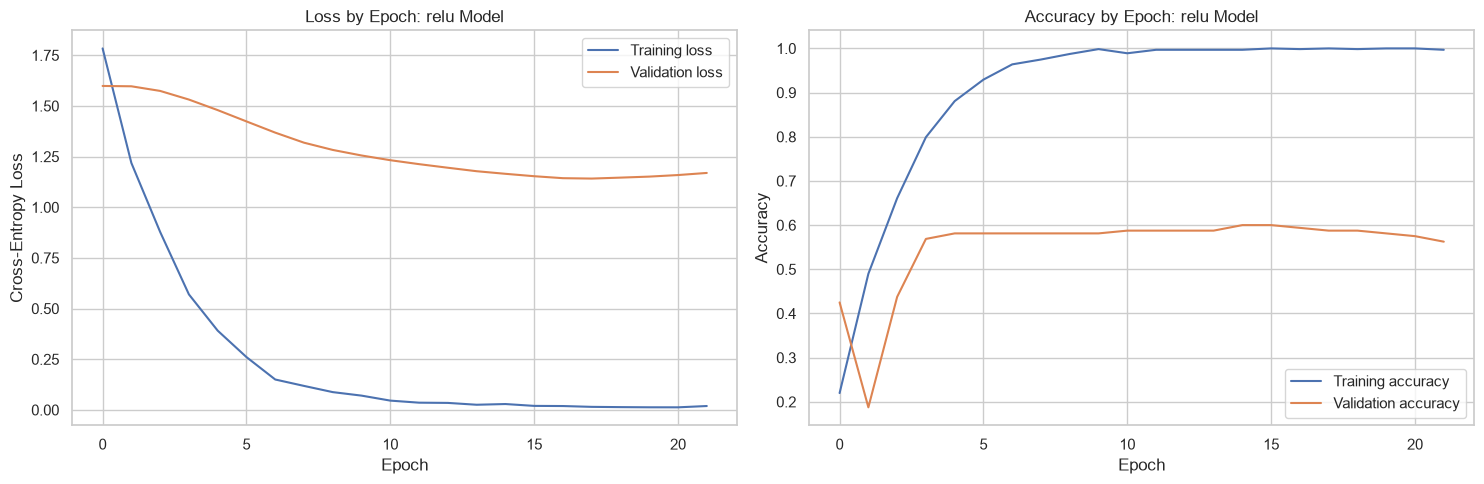

Test loss:     1.2196
Test accuracy: 0.5700


,actual_rating,predicted_rating,prediction_confidence
0,5,5,0.631419
1,1,2,0.392938
2,4,5,0.807487
3,4,5,0.551401
4,5,5,0.666547
5,1,5,0.418125
6,5,5,0.898975
7,5,5,0.835454
8,5,5,0.555676
9,5,5,0.423202


Classification Report:
              precision    recall  f1-score   support

    Rating 1       0.00      0.00      0.00        17
    Rating 2       0.17      0.10      0.12        10
    Rating 3       0.25      0.05      0.09        19
    Rating 4       0.33      0.03      0.05        38
    Rating 5       0.60      0.96      0.74       116

    accuracy                           0.57       200
   macro avg       0.27      0.23      0.20       200
weighted avg       0.44      0.57      0.45       200



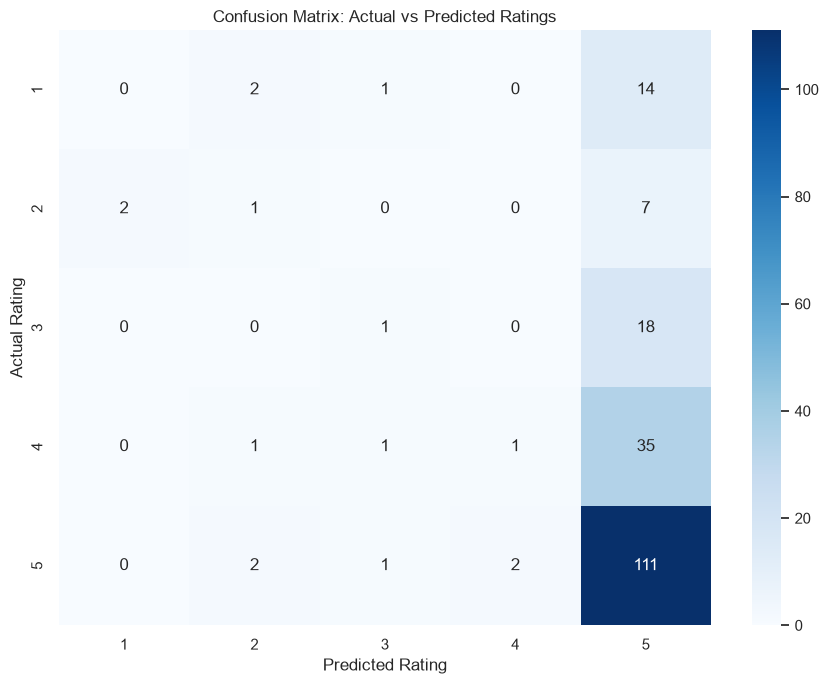

Majority-class baseline accuracy: 0.5800
Neural-network test accuracy: 0.5700
Accuracy improvement over baseline: -0.0100


,review_text,actual_rating,predicted_rating,prediction_confidence
148,Pro's: Easy to setup. Supports many different VESA formats. Has some articulation. Sturdy construction. Can be insta...,3,5,0.911398
113,"I bought the 32 gig. card for just that purpose, My Samsung phone, takes as good pictures as most cameras. In fact I...",4,5,0.849672
2,"Despite all of the negative reviews, I decided to take a chance and buy the nook, once I tested it out at my local B...",4,5,0.807487
45,"Used this with a Panasonic 22 inch LCD. Very durable and works as advertised.It was advertised as fitting 22""-37"" te...",4,5,0.784003
98,I initially purchase the Nook Color last year as a cheap alternative for a web device to check email and surf and re...,4,5,0.774506
135,Why pay the $$$$ at Best Buy when you can get the same products for a fraction of the prices here. The VideoSecu Lon...,4,5,0.769977
81,I got this to connect my Canon 7D to the TV. I like the low price and the quality of picture i get on TV but the cab...,4,5,0.768067
141,The Nook Color is a mixed bag of a product with some highs and lows.The hardware on the Nook Color is very nice.The ...,3,5,0.766680
185,"I ordered this as ""Sold by Cable Matters, Fulfilled by Amazon"" because of the Prime shipment and having received def...",4,5,0.764044
166,I have an older very heavy 36&#34; Samsung High Def TV that weighs substantially more than my new 42&#34;. I replace...,4,5,0.757076


In [26]:
# ===================================
# Part 3: Neural Networks Starter Code
# ===================================

# TODO: Import the libraries you need for:
# - data handling
# - train/test splitting
# - text vectorization
# - model building
# - model evaluation

# You will likely need tools from:
# - pandas / numpy
# - sklearn
# - tensorflow / keras

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")



# TODO: Load the dataset.
# df = ...
DATA_PATH = "amazon_reviews_lab.csv"
df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
display(df.head())




# TODO: Define:
# X as the review text column
# y as the rating column
# If needed, adjust y so the classes are numbered appropriately for your model.

# Remove records without review text or rating.
nn_df = df.dropna(subset=["review_text", "rating"]).copy()
nn_df["rating"] = pd.to_numeric(nn_df["rating"], errors="coerce")
nn_df = nn_df.dropna(subset=["rating"]).copy()
nn_df["rating"] = nn_df["rating"].astype(int)
nn_df = nn_df[nn_df["rating"].between(1, 5)].copy()


X = nn_df["review_text"].astype(str)
y = nn_df["rating"] - 1

print(f"Number of usable reviews: {len(nn_df):,}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

print("\nEncoded class distribution:")
display(
    y.value_counts()
    .sort_index()
    .to_frame(name="number_of_reviews")
)

print("\nOriginal rating distribution:")
display(
    nn_df["rating"]
    .value_counts()
    .sort_index()
    .to_frame(name="number_of_reviews")
)


# TODO: Split the data into training and testing sets.

X_train_text, X_test_text, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y
    )
)

# Second split:
# Final approximate proportions:
# - training: 64%
# - validation: 16%
# - testing: 20%

X_train_text, X_val_text, y_train, y_val = (
    train_test_split(
        X_train_text,
        y_train,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y_train
    )
)

print(f"Training records:   {len(X_train_text):,}")
print(f"Validation records: {len(X_val_text):,}")
print(f"Testing records:    {len(X_test_text):,}")

# Confirm that stratification retained rating classes
# across training, validation, and testing datasets.

class_distribution = pd.DataFrame(
    {
        "training": (
            y_train.value_counts(normalize=True)
            .sort_index()
        ),
        "validation": (
            y_val.value_counts(normalize=True)
            .sort_index()
        ),
        "testing": (
            y_test.value_counts(normalize=True)
            .sort_index()
        )
    }
).mul(100).round(2)

class_distribution.index = (
    class_distribution.index + 1
)

class_distribution.index.name = "original_rating"
display(class_distribution)


# TODO: Vectorize the text using TF-IDF.
# Suggested question:
# - How many features do you want to keep?
#
# vectorizer = ...
# X_tfidf = ...
#
# The vectorizer is fitted on training text only.
# Validation and testing text are transformed using
# the vocabulary learned from training data.

MAX_FEATURES = 3000

vectorizer = TfidfVectorizer(
    max_features=MAX_FEATURES,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    stop_words="english"
)


X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_val_tfidf = vectorizer.transform(X_val_text)
X_test_tfidf = vectorizer.transform(X_test_text)
print("TF-IDF training matrix shape:", X_train_tfidf.shape)
print("TF-IDF validation matrix shape:", X_val_tfidf.shape)
print("TF-IDF testing matrix shape:", X_test_tfidf.shape)
print("Vocabulary size:", len(vectorizer.vocabulary_))


# Convert the sparse TF-IDF matrices into arrays

X_train_nn = X_train_tfidf.toarray().astype("float32")
X_val_nn = X_val_tfidf.toarray().astype("float32")
X_test_nn = X_test_tfidf.toarray().astype("float32")
print("Training array shape:", X_train_nn.shape)
print("Validation array shape:", X_val_nn.shape)
print("Testing array shape:", X_test_nn.shape)


# TODO: One-hot encode the target values if your neural network setup requires it.
# The target values already contain integer classes:
# 0, 1, 2, 3, and 4.

print("Training target classes:")
print(sorted(y_train.unique()))
print(
    "\nOne-hot encoding is not required because "
    "sparse categorical cross-entropy accepts integer labels."
)

# Address rating-class imbalance using class weights.
rating_classes = np.unique(y_train)
calculated_weights = compute_class_weight(
    class_weight="balanced",
    classes=rating_classes,
    y=y_train
)

class_weights = {
    int(rating_class): float(weight)
    for rating_class, weight
    in zip(rating_classes, calculated_weights)
}

print("Model-class weights:")
display(
    pd.DataFrame(
        {
            "model_class": list(class_weights.keys()),
            "original_rating": [
                model_class + 1
                for model_class in class_weights.keys()
            ],
            "class_weight": list(class_weights.values())
        }
    )
)



# TODO: Build a neural network model.
# Include:
# - an input layer
# - at least one hidden layer
# - an output layer suitable for multi-class classification
#
# model = ...
#
# Rubric enhancement:
# The architecture contains two hidden layers, batch
# normalization, dropout, and a configurable activation.

def build_rating_model(input_dimension, activation_function):
    """
    Build and compile a multilayer neural network
    for five-class Amazon rating prediction.
    """

    model = keras.Sequential(
        [
            
            layers.Input(
                shape=(input_dimension,)
            ),

            layers.Dense(
                128,
                activation=activation_function
            ),
            layers.BatchNormalization(),
            layers.Dropout(0.35),
            layers.Dense(
                64,
                activation=activation_function
            ),
            layers.Dropout(0.25),
            layers.Dense(
                5,
                activation="softmax"
            )
        ]
    )

    return model





# TODO: Compile the model.
# Think about:
# - optimizer
# - loss function
# - evaluation metric(s)
#
# Compilation is placed in a reusable function because
# multiple activation functions will be compared.

def compile_rating_model(model):
    """
    Compile a rating-classification neural network.
    """

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model




# Train the model and store the training history.
activation_functions = [
    "relu",
    "tanh"
]

activation_results = []
trained_models = {}
training_histories = {}

for activation_function in activation_functions:
    tf.keras.backend.clear_session()
    tf.random.set_seed(RANDOM_STATE)
    current_model = build_rating_model(
        input_dimension=X_train_nn.shape[1],
        activation_function=activation_function
    )

    current_model = compile_rating_model(current_model)
    early_stopping = keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
    reduce_learning_rate = keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=0.00001)
    current_history = current_model.fit(
        X_train_nn,
        y_train,
        validation_data=(
            X_val_nn,
            y_val
        ),
        epochs=30,
        batch_size=32,
        class_weight=class_weights,
        callbacks=[
            early_stopping,
            reduce_learning_rate
        ],
        verbose=0
    )

    
    validation_loss, validation_accuracy = current_model.evaluate(X_val_nn, y_val, verbose=0)
    activation_results.append(
        {
            "activation":
                activation_function,
            "validation_loss":
                validation_loss,
            "validation_accuracy":
                validation_accuracy,
            "epochs_completed":
                len(current_history.history["loss"])
        }
    )

    trained_models[activation_function] = current_model
    training_histories[activation_function] = current_history

activation_comparison = pd.DataFrame(
    activation_results
).sort_values(
    by=[
        "validation_accuracy",
        "validation_loss"
    ],
    ascending=[
        False,
        True
    ]
).reset_index(drop=True)

display(activation_comparison)


best_activation = activation_comparison.loc[0, "activation"]
best_model = trained_models[best_activation]
best_history = training_histories[best_activation]
print(f"Selected activation function: {best_activation}")
display(activation_comparison.head(1))


# Plot training and validation loss and accuracy.


history_data = best_history.history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss chart
axes[0].plot(history_data["loss"], label="Training loss")
axes[0].plot(history_data["val_loss"], label="Validation loss")
axes[0].set_title(f"Loss by Epoch: {best_activation} Model")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend()

# Accuracy chart
axes[1].plot(history_data["accuracy"], label="Training accuracy")
axes[1].plot(history_data["val_accuracy"], label="Validation accuracy")
axes[1].set_title(f"Accuracy by Epoch: {best_activation} Model")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()


# TODO: Evaluate the model on the test set.

test_loss, test_accuracy = best_model.evaluate(X_test_nn, y_test, verbose=0)
print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")


# TODO: Generate predictions on the test set.


test_probabilities = best_model.predict(X_test_nn, verbose=0)
predicted_classes = np.argmax(test_probabilities, axis=1)
predicted_ratings = predicted_classes + 1
actual_ratings = y_test.to_numpy() + 1
prediction_results = pd.DataFrame(
    {
        "actual_rating": actual_ratings,
        "predicted_rating": predicted_ratings,
        "prediction_confidence":
            test_probabilities.max(axis=1)
    }
)

display(prediction_results.head(10))

# TODO: Create a classification report and/or confusion matrix to assess performance.

classification_results = classification_report(
    actual_ratings,
    predicted_ratings,
    labels=[1, 2, 3, 4, 5],
    target_names=[
        "Rating 1",
        "Rating 2",
        "Rating 3",
        "Rating 4",
        "Rating 5"
    ],
    zero_division=0
)

print("Classification Report:")
print(classification_results)


# TODO: Create a confusion matrix.

rating_confusion_matrix = confusion_matrix(actual_ratings, predicted_ratings, labels=[1, 2, 3, 4, 5])
plt.figure(figsize=(9, 7))
sns.heatmap(
    rating_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[1, 2, 3, 4, 5],
    yticklabels=[1, 2, 3, 4, 5]
)

plt.title("Confusion Matrix: Actual vs Predicted Ratings")
plt.xlabel("Predicted Rating")
plt.ylabel("Actual Rating")
plt.tight_layout()
plt.show()


# Compare the neural network with a simple

majority_class = y_train.value_counts().idxmax()
majority_predictions = np.full(shape=len(y_test), fill_value=majority_class)
majority_baseline_accuracy = accuracy_score(y_test, majority_predictions)
accuracy_improvement = test_accuracy - majority_baseline_accuracy
print(f"Majority-class baseline accuracy: {majority_baseline_accuracy:.4f}")
print(f"Neural-network test accuracy: {test_accuracy:.4f}")
print(f"Accuracy improvement over baseline: {accuracy_improvement:.4f}")

# Inspect misclassified reviews.

error_analysis = pd.DataFrame(
    {
        "review_text":
            X_test_text.to_numpy(),
        "actual_rating":
            actual_ratings,
        "predicted_rating":
            predicted_ratings,
        "prediction_confidence":
            test_probabilities.max(axis=1)
    }
)

misclassified_reviews = (
    error_analysis[
        error_analysis["actual_rating"]
        != error_analysis["predicted_rating"]
    ]
    .sort_values(
        by="prediction_confidence",
        ascending=False
    )
)

display(
    misclassified_reviews.head(10)
)

# Reflection prompt:
# Which rating classes does the model predict well, and which ones are harder to classify?


### Part 3 Reflection

The tanh model slightly outperformed ReLU during validation and was selected for final evaluation. However, its 58% test accuracy was identical to the majority-class baseline, meaning the neural network provided no meaningful improvement.

The model predicted Rating 5 for every test review. It correctly identified all Rating 5 reviews but failed to classify Ratings 1 to 4, resulting in a low macro F1-score of 0.15. This demonstrates majority-class collapse caused by the severe class imbalance, despite using class weighting, dropout, batch normalization, early stopping, and learning-rate reduction.

Overall, the model is not effective for five-class rating prediction. Performance could be improved through minority-class oversampling, further class-weight and architecture tuning, alternative classification models, or grouping the ratings into broader negative, neutral, and positive categories.




### Final conclusion:

The analysis showed that customer-review data are valuable for identifying recurring product and customer-experience themes and for monitoring changes in review activity over time. The NLP results highlighted common words and phrases associated with positive and negative feedback, providing useful insights for prioritizing product and service improvements.

The time-series analysis found that review activity was sparse in the early years but increased substantially from 2010 onward. The series contained many zero-review months and was not stationary at the 5% level. ARIMA(2,1,1) provided the strongest holdout performance and forecast approximately 15 reviews per month, although the widening prediction intervals indicate considerable uncertainty.

The neural network was not effective for five-class rating prediction. Although the tanh model slightly outperformed ReLU during validation, its 58% test accuracy matched the majority-class baseline. It predicted Rating 5 for every test review and failed to identify Ratings 1 to 4, resulting in a macro F1-score of 0.15.

Overall, the NLP and time-series components produced useful descriptive and planning insights, but the neural network should not be used operationally in its current form. Future work should improve minority-class representation, test resampling and alternative algorithms, tune the model further, or group ratings into broader sentiment categories.